In [ ]:
# ============================================================
# Sto-SQP-PINN for 1D Allen-Cahn Equation (JAX)
#
# PDE:
#     u_t - eps*u_xx + a*u^3 - a*u = 0,
#     (x,t) in [-1,1] x [0,1]
#
# Standard benchmark parameters:
#     eps = 1e-4, a = 5
#
# IC:
#     u(x,0) = x^2 cos(pi x)
#
# Periodic BC:
#     u(-1,t) = u(1,t)
#     u_x(-1,t) = u_x(1,t)
#
# Reference data:
#     Put allen_cahn.mat in ./data/allen_cahn.mat or ./allen_cahn.mat
#     Expected variables: t, x, usol
#     MATLAB generator usually saves usol with shape (201, 512).
#
# SQP details:
#   - fixed base collocation/BC/IC sets
#   - fresh Gaussian jitter each iteration
#   - raw signed equality constraints, not squared constraints
#   - fixed damped KKT lambda = 1e-4
#   - derivative periodic BC is INCLUDED, unlike transport
# ============================================================

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import math
from functools import partial
from pathlib import Path

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

import jax.numpy as jnp
from jax import random, grad, vmap, hessian

DTYPE = jnp.float64
EPS = DTYPE(1e-12)

# ============================================================
# Problem setup
# ============================================================
X_MIN = -1.0
X_MAX = 1.0
T_MIN = 0.0
T_MAX = 1.0

EPS_AC = 1.0e-3
A_AC = 5.0

# Reference data path
MAT_PATHS = [
    
    "allen_cahn_python.mat",
]

# If you want a smaller evaluation grid, change this after loading.
# For the Chebfun data, x has 512 points and t has 201 points.
B_DATA = 0

# ============================================================
# Constraint counts
# ============================================================
NX_PDE_CON = 30
NT_PDE_CON = 30
K_PDE = NX_PDE_CON * NT_PDE_CON
N_PDE_PER_CELL = 1

K_BC = 100
N_BC_PER_BIN = 1

K_IC = 200
N_IC_PER_BIN = 1

# Allen-Cahn has value-periodic BC and derivative-periodic BC.
M_CON = K_PDE + 2 * K_BC + K_IC

# PDE objective points
NX_PDE_OBJ = 80
NT_PDE_OBJ = 80
K_PDE_OBJ = NX_PDE_OBJ * NT_PDE_OBJ

# Network
HIDDEN_DIM = 30
NUM_HIDDEN = 3

# Training
MAX_ITERS = 10000
PRINT_EVERY = 10

MU_DAMP = 1e-4
L_LIP = 80.0
GAMMA_LIP = 80.0

BETA0 = 1.0
BETA_SHIFT = 200.0
BETA_POWER = 0.6

W_PDE_OBJ = 10.0
MC_PDE_OBJ_JITTER = 8

# Jitter. For Allen-Cahn no large advection speed, so equal small jitter is okay.
JITTER_EVERY_ITER = True
JITTER_KIND = "gaussian"
JITTER_SIGMA_X = 1e-3
JITTER_SIGMA_T = 1e-3
JITTER_OBJ_SIGMA_X = 1e-3
JITTER_OBJ_SIGMA_T = 1e-3
JITTER_CLIP_K = 2.0

SEED = 0
SAVE_PREFIX = "allen_cahn_stosqp"


# ============================================================
# Load reference data
# ============================================================
def load_allen_cahn_mat(paths=MAT_PATHS):
    chosen = None
    for p in paths:
        if Path(p).exists():
            chosen = p
            break
    if chosen is None:
        raise FileNotFoundError(
            "Could not find allen_cahn.mat. Put it at ./data/allen_cahn.mat or ./allen_cahn.mat"
        )

    d = scipy.io.loadmat(chosen)
    t = np.asarray(d["t"]).squeeze()
    x = np.asarray(d["x"]).squeeze()
    usol = np.asarray(d["usol"])

    # Expected from your MATLAB code: usol shape = (steps+1, nn+1) = (201,512).
    # If it is transposed, fix it.
    if usol.shape == (x.size, t.size):
        usol = usol.T

    if usol.shape != (t.size, x.size):
        raise ValueError(f"Unexpected usol shape {usol.shape}; expected {(t.size, x.size)}")

    return t.astype(np.float64), x.astype(np.float64), usol.astype(np.float64), chosen


def build_full_data_points(t_np, x_np, usol_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    X_data = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    u_data = usol_np.reshape(-1)
    return X_data, u_data


# ============================================================
# MLP
# ============================================================
def init_mlp_params(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        W = random.normal(k, (m, n), dtype=DTYPE) * jnp.sqrt(DTYPE(2.0) / DTYPE(m))
        b = jnp.zeros((n,), dtype=DTYPE)
        params.append({"W": W, "b": b})
    return params


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]
    x_n = DTYPE(2.0) * (x - DTYPE(X_MIN)) / (DTYPE(X_MAX) - DTYPE(X_MIN)) - DTYPE(1.0)
    t_n = DTYPE(2.0) * (t - DTYPE(T_MIN)) / (DTYPE(T_MAX) - DTYPE(T_MIN)) - DTYPE(1.0)
    return jnp.concatenate([x_n, t_n], axis=1)


def mlp_apply(params, X):
    h = normalize_xt(X)
    for i, layer in enumerate(params):
        W, b = layer["W"], layer["b"]
        h = h @ W + b
        if i < len(params) - 1:
            h = jnp.tanh(h)
    return h


def flatten_params(params):
    flat_parts = []
    shapes = []
    for layer in params:
        W, b = layer["W"], layer["b"]
        flat_parts.append(W.reshape(-1))
        flat_parts.append(b.reshape(-1))
        shapes.append((W.shape, b.shape))
    theta = jnp.concatenate(flat_parts).astype(DTYPE)
    return theta, tuple(shapes)


def unflatten_params(theta, shapes):
    params = []
    idx = 0
    for W_shape, b_shape in shapes:
        W_size = math.prod(W_shape)
        b_size = math.prod(b_shape)
        W = theta[idx:idx + W_size].reshape(W_shape)
        idx += W_size
        b = theta[idx:idx + b_size].reshape(b_shape)
        idx += b_size
        params.append({"W": W, "b": b})
    return params


# ============================================================
# Sampling
# ============================================================
def segment_sum(values, segment_ids, num_segments):
    out = jnp.zeros((num_segments,), dtype=values.dtype)
    return out.at[segment_ids].add(values)


def sample_data_batch(key, X_data, u_data, B):
    if B == 0:
        return jnp.zeros((0, 2), dtype=DTYPE), jnp.zeros((0,), dtype=DTYPE)
    N = X_data.shape[0]
    idx = random.randint(key, (B,), 0, N)
    return X_data[idx], u_data[idx]


def sample_pde_obj_base_stratified(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_OBJ)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_OBJ)

    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_OBJ), jnp.arange(NX_PDE_OBJ), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE_OBJ, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0 + u[:, 0] * dx
    ts = t0 + u[:, 1] * dt
    return jnp.stack([xs, ts], axis=1)


def sample_pde_stratified(key, x_min, x_max, t_min, t_max):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(NX_PDE_CON)
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(NT_PDE_CON)

    it, ix = jnp.meshgrid(jnp.arange(NT_PDE_CON), jnp.arange(NX_PDE_CON), indexing="ij")
    it = it.reshape(-1).astype(jnp.int32)
    ix = ix.reshape(-1).astype(jnp.int32)
    ids_cell = (it * NX_PDE_CON + ix).astype(jnp.int32)

    x0 = DTYPE(x_min) + DTYPE(ix) * dx
    t0 = DTYPE(t_min) + DTYPE(it) * dt

    u = random.uniform(key, (K_PDE, N_PDE_PER_CELL, 2), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = x0[:, None] + u[:, :, 0] * dx
    ts = t0[:, None] + u[:, :, 1] * dt

    X_f = jnp.stack([xs, ts], axis=-1).reshape(-1, 2)
    ids = jnp.repeat(ids_cell, N_PDE_PER_CELL)
    return X_f, ids


def sample_bc_stratified(key, x_min, x_max, t_min, t_max):
    # Periodic boundary pairs with matched times.
    dt = (DTYPE(t_max) - DTYPE(t_min)) / DTYPE(K_BC)
    j = jnp.arange(K_BC, dtype=jnp.int32)
    t0 = DTYPE(t_min) + DTYPE(j) * dt

    u = random.uniform(key, (K_BC, N_BC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    ts = (t0[:, None] + u * dt).reshape(-1, 1)
    ids = jnp.repeat(j, N_BC_PER_BIN)

    XL = jnp.concatenate([DTYPE(x_min) * jnp.ones_like(ts), ts], axis=1)
    XR = jnp.concatenate([DTYPE(x_max) * jnp.ones_like(ts), ts], axis=1)
    return XL, XR, ids


def allen_cahn_ic_target(x):
    return x ** 2 * jnp.cos(jnp.pi * x)


def sample_ic_stratified(key, x_min, x_max, t0):
    dx = (DTYPE(x_max) - DTYPE(x_min)) / DTYPE(K_IC)
    j = jnp.arange(K_IC, dtype=jnp.int32)
    x0 = DTYPE(x_min) + DTYPE(j) * dx

    u = random.uniform(key, (K_IC, N_IC_PER_BIN), minval=0.0, maxval=1.0, dtype=DTYPE)
    xs = (x0[:, None] + u * dx).reshape(-1, 1)
    ids = jnp.repeat(j, N_IC_PER_BIN)

    Xic = jnp.concatenate([xs, DTYPE(t0) * jnp.ones_like(xs)], axis=1)
    u0 = allen_cahn_ic_target(xs[:, 0])
    return Xic, u0, ids


# ============================================================
# Jitter
# ============================================================
def jitter_points(key, X, x_min, x_max, t_min, t_max,
                  sigma_x, sigma_t, kind="gaussian", clip_k=2.0):
    if X.shape[0] == 0 or ((sigma_x <= 0.0) and (sigma_t <= 0.0)):
        return X

    key, kx, kt = random.split(key, 3)

    if kind == "gaussian":
        dx = DTYPE(sigma_x) * random.normal(kx, (X.shape[0],), dtype=DTYPE)
        dt = DTYPE(sigma_t) * random.normal(kt, (X.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dx = jnp.clip(dx, -k * DTYPE(sigma_x), k * DTYPE(sigma_x))
            dt = jnp.clip(dt, -k * DTYPE(sigma_t), k * DTYPE(sigma_t))
    elif kind == "uniform":
        dx = DTYPE(sigma_x) * (DTYPE(2.0) * random.uniform(kx, (X.shape[0],), dtype=DTYPE) - DTYPE(1.0))
        dt = DTYPE(sigma_t) * (DTYPE(2.0) * random.uniform(kt, (X.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    x = jnp.clip(X[:, 0] + dx, DTYPE(x_min), DTYPE(x_max))
    t = jnp.clip(X[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    return jnp.stack([x, t], axis=1)


def jitter_bc_pair_time(key, XL, XR, x_min, x_max, t_min, t_max,
                        sigma_t, kind="gaussian", clip_k=2.0):
    # Same time noise for left and right boundary point pairs.
    if XL.shape[0] == 0 or sigma_t <= 0.0:
        return XL, XR

    if kind == "gaussian":
        dt = DTYPE(sigma_t) * random.normal(key, (XL.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dt = jnp.clip(dt, -k * DTYPE(sigma_t), k * DTYPE(sigma_t))
    elif kind == "uniform":
        dt = DTYPE(sigma_t) * (DTYPE(2.0) * random.uniform(key, (XL.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    tL = jnp.clip(XL[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))
    tR = jnp.clip(XR[:, 1] + dt, DTYPE(t_min), DTYPE(t_max))

    XL_use = jnp.stack([DTYPE(x_min) * jnp.ones_like(tL), tL], axis=1)
    XR_use = jnp.stack([DTYPE(x_max) * jnp.ones_like(tR), tR], axis=1)
    return XL_use, XR_use


def jitter_ic_x(key, Xic, x_min, x_max, t_min, sigma_x, kind="gaussian", clip_k=2.0):
    if Xic.shape[0] == 0 or sigma_x <= 0.0:
        return Xic, allen_cahn_ic_target(Xic[:, 0])

    if kind == "gaussian":
        dx = DTYPE(sigma_x) * random.normal(key, (Xic.shape[0],), dtype=DTYPE)
        if clip_k is not None:
            k = DTYPE(clip_k)
            dx = jnp.clip(dx, -k * DTYPE(sigma_x), k * DTYPE(sigma_x))
    elif kind == "uniform":
        dx = DTYPE(sigma_x) * (DTYPE(2.0) * random.uniform(key, (Xic.shape[0],), dtype=DTYPE) - DTYPE(1.0))
    else:
        raise ValueError("kind must be 'gaussian' or 'uniform'")

    x = jnp.clip(Xic[:, 0] + dx, DTYPE(x_min), DTYPE(x_max))
    t = DTYPE(t_min) * jnp.ones_like(x)
    Xic_use = jnp.stack([x, t], axis=1)
    u0ic_use = allen_cahn_ic_target(x)
    return Xic_use, u0ic_use


# ============================================================
# Allen-Cahn residual
# ============================================================
def pde_residual(params, X, eps_ac=EPS_AC, a_ac=A_AC):
    """
    Allen-Cahn residual:
        r = u_t - eps*u_xx + a*u^3 - a*u

    The optional constant scaling by max(1,a) improves conditioning and does
    not change the equality constraint.
    """
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    u = vmap(u_fun)(X)
    du = vmap(grad(u_fun))(X)
    H = vmap(hessian(u_fun))(X)

    u_t = du[:, 1]
    u_xx = H[:, 0, 0]

    r = u_t - DTYPE(eps_ac) * u_xx + DTYPE(a_ac) * u ** 3 - DTYPE(a_ac) * u
    return r / jnp.maximum(DTYPE(1.0), DTYPE(a_ac))


def pde_mse_on_points(theta, shapes, X_pts, eps_ac=EPS_AC, a_ac=A_AC):
    params = unflatten_params(theta, shapes)
    r = pde_residual(params, X_pts, eps_ac, a_ac)
    return jnp.mean(r ** 2)


# ============================================================
# Objective
# ============================================================
def data_mse_unscaled(params, Xb, ub):
    if Xb.shape[0] == 0:
        return DTYPE(0.0)
    pred = mlp_apply(params, Xb)[:, 0]
    return jnp.mean((pred - ub) ** 2)


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_data_scaled_batch(theta, shapes, Xb, ub, scale_obj):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        return data_mse_unscaled(params, Xb, ub)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return DTYPE(scale_obj) * val, DTYPE(scale_obj) * g


@partial(jax.jit, static_argnames=("shapes",))
def F_and_g_pde_obj(theta, shapes, X_obj, eps_ac, a_ac, w_pde):
    def obj_theta(th):
        params = unflatten_params(th, shapes)
        r = pde_residual(params, X_obj, eps_ac, a_ac)
        return DTYPE(w_pde) * jnp.mean(r ** 2)

    val, g = jax.value_and_grad(obj_theta)(theta)
    return val, g


# ============================================================
# Constraint vector
# ============================================================
@partial(jax.jit, static_argnames=("shapes",))
def constraint_vector(theta, shapes,
                      X_f, ids_f,
                      X_bc_L, X_bc_R, ids_bc,
                      X_ic, u0_ic, ids_ic,
                      eps_ac, a_ac):
    params = unflatten_params(theta, shapes)

    # PDE constraints
    r = pde_residual(params, X_f, eps_ac, a_ac)
    c_pde = segment_sum(r, ids_f, K_PDE) / DTYPE(N_PDE_PER_CELL)

    # BC: value periodic and derivative periodic
    def u_fun(xt):
        return mlp_apply(params, xt[None, :])[0, 0]

    uL = mlp_apply(params, X_bc_L)[:, 0]
    uR = mlp_apply(params, X_bc_R)[:, 0]
    c_bc_val = segment_sum(uL - uR, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)

    uxL = vmap(lambda z: grad(u_fun)(z)[0])(X_bc_L)
    uxR = vmap(lambda z: grad(u_fun)(z)[0])(X_bc_R)
    c_bc_der = segment_sum(uxL - uxR, ids_bc, K_BC) / DTYPE(N_BC_PER_BIN)

    # IC
    u_ic = mlp_apply(params, X_ic)[:, 0]
    c_ic = segment_sum(u_ic - u0_ic, ids_ic, K_IC) / DTYPE(N_IC_PER_BIN)

    return jnp.concatenate([c_pde, c_bc_val, c_bc_der, c_ic], axis=0)


@partial(jax.jit, static_argnames=("shapes",))
def C_and_J(theta, shapes,
            X_f, ids_f,
            X_bc_L, X_bc_R, ids_bc,
            X_ic, u0_ic, ids_ic,
            eps_ac, a_ac):
    def c_fun(th):
        return constraint_vector(th, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, eps_ac, a_ac)

    def c_fun_aux(th):
        c = c_fun(th)
        return c, c

    J, c = jax.jacrev(c_fun_aux, has_aux=True)(theta)
    return c, J


@partial(jax.jit, static_argnames=("shapes",))
def C_only(theta, shapes,
           X_f, ids_f,
           X_bc_L, X_bc_R, ids_bc,
           X_ic, u0_ic, ids_ic,
           eps_ac, a_ac):
    return constraint_vector(theta, shapes, X_f, ids_f, X_bc_L, X_bc_R, ids_bc, X_ic, u0_ic, ids_ic, eps_ac, a_ac)


# ============================================================
# Fixed damped KKT solve
# ============================================================
@jax.jit
def kkt_solve_fixed(H, Jac, Grad, Cons, mu_damp):
    n = H.shape[0]
    m = Cons.shape[0]

    top = jnp.concatenate([H, Jac.T], axis=1)
    bottom = jnp.concatenate([Jac, -mu_damp * jnp.eye(m, dtype=H.dtype)], axis=1)
    KKT = jnp.concatenate([top, bottom], axis=0)

    rhs = -jnp.concatenate([Grad, Cons])
    sol = jnp.linalg.solve(KKT, rhs)
    d = sol[:n]
    y = sol[n:]

    res_vec = jnp.concatenate([
        H @ d + Jac.T @ y + Grad,
        Jac @ d + Cons - mu_damp * y,
    ])
    kkt_res = jnp.linalg.norm(res_vec, 2)
    return d, y, kkt_res


# ============================================================
# Step length helpers
# ============================================================
def cal_tau_mu(H, d, sigma, tau_pre, eps_tau, g, c, mu_eff, y):
    denom = float(g @ d + 0.5 * (d @ (H @ d)))
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    if (denom <= 1e-12) or (delta_c <= 0.0):
        tau_trial = float("inf")
    else:
        tau_trial = (1.0 - sigma) * delta_c / denom

    if tau_pre <= tau_trial:
        return tau_pre
    return min(tau_trial, (1.0 - eps_tau) * tau_pre)


def cal_ksi_mu(d, tau, ksi_old, eps_ksi, g, c, mu_eff, y):
    d2 = float(jnp.linalg.norm(d) ** 2)
    if d2 <= 1e-18 or tau <= 1e-18:
        return ksi_old

    gd = float(g @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    Dl = -tau * gd + delta_c
    ksi_trial = max(0.0, Dl / (tau * d2))

    if ksi_old <= ksi_trial:
        return ksi_old
    return min(ksi_trial, (1.0 - eps_ksi) * ksi_old)


def phi_mu(alpha, eta, beta, tau, g, d, c, mu_eff, y, L, Gamma):
    gd = float(g @ d)
    d2 = float(d @ d)
    c1 = float(jnp.linalg.norm(c, 1))
    mu_y1 = float(jnp.linalg.norm(DTYPE(mu_eff) * y, 1))
    delta_c = c1 - mu_y1

    Dl = -tau * gd + delta_c
    term1 = (eta - 1.0) * alpha * beta * Dl
    term2 = (abs(1.0 - alpha) - 1.0 + alpha) * c1
    term3 = 0.5 * (tau * L + Gamma) * (alpha ** 2) * d2
    return term1 + term2 + term3


def cal_alpha_mu(d, eta, beta, ksi, tau, L, Gamma, theta_val, g, c, mu_eff, y):
    denom = tau * L + Gamma
    if denom <= 1e-12:
        return 0.0

    alpha_min = 2.0 * (1.0 - eta) * beta * ksi * tau / denom
    a = max(alpha_min, 0.0)

    while (
        phi_mu(1.1 * a, eta, beta, tau, g, d, c, mu_eff, y, L, Gamma) < 0.0
        and (1.1 * a < alpha_min + theta_val * beta)
    ):
        a *= 1.1

    return float(a)


# ============================================================
# Diagnostics
# ============================================================
def rms(x):
    return float(jnp.sqrt(jnp.mean(x ** 2) + DTYPE(1e-30)))


def split_constraint_blocks(c):
    i0 = 0
    c_pde = c[i0:i0 + K_PDE]
    i0 += K_PDE
    c_bcv = c[i0:i0 + K_BC]
    i0 += K_BC
    c_bcd = c[i0:i0 + K_BC]
    i0 += K_BC
    c_ic = c[i0:]
    return c_pde, c_bcv, c_bcd, c_ic


def print_header():
    print(
        f"{'iter':>6s} | {'obj':>10s} | {'pdeMSE':>10s} | {'feas':>10s} | "
        f"{'PDE':>9s} | {'BCv':>9s} | {'BCd':>9s} | {'IC':>9s} | "
        f"{'stat':>9s} | {'alpha':>9s} | {'stepInf':>9s} | "
        f"{'lam':>8s} | {'kkt':>9s} | {'relL2':>9s} | {'tau':>9s}"
    )
    print("-" * 170)


@partial(jax.jit, static_argnames=("shapes",))
def predict_u(theta, shapes, X):
    params = unflatten_params(theta, shapes)
    return mlp_apply(params, X)[:, 0]


def make_grid_points(x_np, t_np):
    TT, XX = np.meshgrid(t_np, x_np, indexing="ij")
    X_grid = np.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    return X_grid, TT.shape


def eval_full_grid(theta, shapes, x_np, t_np, usol_np):
    X_grid_np, grid_shape = make_grid_points(x_np, t_np)
    X_grid = jnp.array(X_grid_np, dtype=DTYPE)
    u_pred = np.array(predict_u(theta, shapes, X_grid)).reshape(grid_shape)
    u_true = usol_np
    mse = float(np.mean((u_pred - u_true) ** 2))
    rel_l2 = float(np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + 1e-12))
    return mse, rel_l2, u_pred


def save_heatmaps(x_np, t_np, u_true, u_pred, prefix=SAVE_PREFIX):
    err = np.abs(u_pred - u_true)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for ax, arr, title in zip(axes, [u_true, u_pred, err], ["Exact", "Predicted", "Absolute error"]):
        im = ax.imshow(
            arr.T,
            origin="lower",
            aspect="auto",
            extent=[t_np[0], t_np[-1], x_np[0], x_np[-1]],
            interpolation="nearest",
        )
        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$x$")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    out = f"{prefix}_heatmaps.png"
    plt.savefig(out, dpi=250)
    print(f"Saved heatmaps -> {out}")
    plt.show()


# ============================================================
# Training
# ============================================================
def train_sqp_allen_cahn(
    theta0, shapes,
    X_data, u_data,
    x_np, t_np, usol_np,
    x_min=X_MIN, x_max=X_MAX, t_min=T_MIN, t_max=T_MAX,
    eps_ac=EPS_AC, a_ac=A_AC,
    scale_obj=1.0,
    max_iters=MAX_ITERS,
    print_every=PRINT_EVERY,
    beta0=BETA0,
    beta_shift=BETA_SHIFT,
    beta_power=BETA_POWER,
    L_lip=L_LIP,
    Gamma_lip=GAMMA_LIP,
    mu_damp=MU_DAMP,
    seed=SEED,
    hold_data_K=10000,
    hold_con_K=10000,
    hold_obj_K=10000,
    jitter_every_iter=JITTER_EVERY_ITER,
    jitter_kind=JITTER_KIND,
    jitter_sigma_x=JITTER_SIGMA_X,
    jitter_sigma_t=JITTER_SIGMA_T,
    jitter_obj_sigma_x=JITTER_OBJ_SIGMA_X,
    jitter_obj_sigma_t=JITTER_OBJ_SIGMA_T,
    jitter_clip_k=JITTER_CLIP_K,
    mc_pde_obj_jitter=MC_PDE_OBJ_JITTER,
    w_pde_obj=W_PDE_OBJ,
):
    key = random.PRNGKey(seed)
    theta = theta0
    n = theta.shape[0]
    H = jnp.eye(n, dtype=DTYPE)

    eta, sigma = 0.25, 0.1
    eps_tau, eps_ksi = 1e-2, 1e-2
    theta_val = 10.0
    tau_k, ksi_k = 5.0, 1.0

    Xb = ub = None
    Xf = ids_f = None
    XL = XR = ids_bc = None
    Xic = u0ic = ids_ic = None
    X_obj_base = None

    best_rel = np.inf
    best_theta = np.asarray(theta)

    print(f"Allen-Cahn data: t {t_np.shape}, x {x_np.shape}, usol {usol_np.shape}")
    print(f"Domain: x in [{x_min}, {x_max}], t in [{t_min}, {t_max}]")
    print(f"PDE: u_t - {eps_ac:g} u_xx + {a_ac:g} u^3 - {a_ac:g} u = 0")
    print(f"Constraint dimension M_CON = {M_CON}")
    print(f"Fixed damping lambda = {mu_damp:.1e}")
    print(f"Jitter: kind={jitter_kind}, sigma_x={jitter_sigma_x:.1e}, sigma_t={jitter_sigma_t:.1e}")
    print(f"Constraint blocks: PDE={K_PDE}, BCv={K_BC}, BCd={K_BC}, IC={K_IC}")
    print_header()

    t0 = time.time()

    for k in range(1, max_iters + 1):
        k_beta = (k // 10) * 10
        beta_k = float(min(1.0, beta0 * (beta_shift / (beta_shift + k_beta)) ** beta_power))

        if (k == 1) or ((k - 1) % int(hold_data_K) == 0) or (Xb is None):
            key, k_data = random.split(key)
            Xb, ub = sample_data_batch(k_data, X_data, u_data, B_DATA)

        if (k == 1) or ((k - 1) % int(hold_obj_K) == 0) or (X_obj_base is None):
            key, k_obj = random.split(key)
            X_obj_base = sample_pde_obj_base_stratified(k_obj, x_min, x_max, t_min, t_max)

        if (k == 1) or ((k - 1) % int(hold_con_K) == 0) or (Xf is None):
            key, k_f, k_bc, k_ic = random.split(key, 4)
            Xf, ids_f = sample_pde_stratified(k_f, x_min, x_max, t_min, t_max)
            XL, XR, ids_bc = sample_bc_stratified(k_bc, x_min, x_max, t_min, t_max)
            Xic, u0ic, ids_ic = sample_ic_stratified(k_ic, x_min, x_max, t_min)

        # Objective gradient
        obj_d, g_d = F_and_g_data_scaled_batch(theta, shapes, Xb, ub, scale_obj)

        obj_r_acc = DTYPE(0.0)
        g_r_acc = jnp.zeros((n,), dtype=DTYPE)

        for _ in range(int(mc_pde_obj_jitter)):
            key, kj_obj = random.split(key)
            X_obj_use = jitter_points(
                kj_obj, X_obj_base, x_min, x_max, t_min, t_max,
                jitter_obj_sigma_x, jitter_obj_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
            obj_r, g_r = F_and_g_pde_obj(theta, shapes, X_obj_use, eps_ac, a_ac, w_pde_obj)
            obj_r_acc = obj_r_acc + obj_r
            g_r_acc = g_r_acc + g_r

        obj_s = obj_d + obj_r_acc / DTYPE(int(mc_pde_obj_jitter))
        g_s = g_d + g_r_acc / DTYPE(int(mc_pde_obj_jitter))

        # Jitter constraints
        if jitter_every_iter:
            key, kj_f, kj_bc, kj_ic = random.split(key, 4)

            Xf_use = jitter_points(
                kj_f, Xf, x_min, x_max, t_min, t_max,
                jitter_sigma_x, jitter_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )

            XL_use, XR_use = jitter_bc_pair_time(
                kj_bc, XL, XR, x_min, x_max, t_min, t_max,
                jitter_sigma_t,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )

            Xic_use, u0ic_use = jitter_ic_x(
                kj_ic, Xic, x_min, x_max, t_min,
                jitter_sigma_x,
                kind=jitter_kind, clip_k=jitter_clip_k,
            )
        else:
            Xf_use, XL_use, XR_use, Xic_use, u0ic_use = Xf, XL, XR, Xic, u0ic

        Cons, Jac = C_and_J(
            theta, shapes,
            Xf_use, ids_f,
            XL_use, XR_use, ids_bc,
            Xic_use, u0ic_use, ids_ic,
            eps_ac, a_ac,
        )

        d, y, kkt_res = kkt_solve_fixed(H, Jac, g_s, Cons, DTYPE(mu_damp))

        dn = float(jnp.linalg.norm(d, jnp.inf))
        if dn > 1e-10:
            tau_k = cal_tau_mu(H, d, sigma, tau_k, eps_tau, g_s, Cons, DTYPE(mu_damp), y)
            ksi_k = cal_ksi_mu(d, tau_k, ksi_k, eps_ksi, g_s, Cons, DTYPE(mu_damp), y)
            alpha = cal_alpha_mu(d, eta, beta_k, ksi_k, tau_k, L_lip, Gamma_lip, theta_val, g_s, Cons, DTYPE(mu_damp), y)
        else:
            alpha = 0.0

        alpha = float(alpha)

        theta = theta + DTYPE(alpha) * d

        if k % int(print_every) == 0:
            c_now = C_only(
                theta, shapes,
                Xf_use, ids_f,
                XL_use, XR_use, ids_bc,
                Xic_use, u0ic_use, ids_ic,
                eps_ac, a_ac,
            )
            c_pde, c_bcv, c_bcd, c_ic = split_constraint_blocks(c_now)

            feas = float(jnp.mean(c_now ** 2))
            pde_rms = rms(c_pde)
            bcv_rms = rms(c_bcv)
            bcd_rms = rms(c_bcd)
            ic_rms = rms(c_ic)

            station = float(jnp.linalg.norm(g_s + Jac.T @ y, jnp.inf))
            step_inf = float(alpha * dn)
            pde_obj_mse = float(pde_mse_on_points(theta, shapes, X_obj_base, eps_ac, a_ac))

            _, rel_l2, _ = eval_full_grid(theta, shapes, x_np, t_np, usol_np)

            if rel_l2 < best_rel:
                best_rel = rel_l2
                best_theta = np.asarray(theta)
                np.save(f"{SAVE_PREFIX}_best.npy", best_theta)

            print(
                f"{k:6d} | {float(obj_s):10.3e} | {pde_obj_mse:10.3e} | {feas:10.3e} | "
                f"{pde_rms:9.2e} | {bcv_rms:9.2e} | {bcd_rms:9.2e} | {ic_rms:9.2e} | "
                f"{station:9.2e} | {alpha:9.2e} | {step_inf:9.2e} | "
                f"{mu_damp:8.1e} | {float(kkt_res):9.2e} | {rel_l2:9.2e} | {tau_k:9.2e}"
                
            )

            if (not np.isfinite(feas)) or (not np.isfinite(rel_l2)) or dn > 1e10:
                print("Stopping early: instability detected.")
                break

    print(f"[done] elapsed={time.time() - t0:.2f}s")
    print(f"[best] relL2={best_rel:.3e}")
    return jnp.asarray(best_theta, dtype=DTYPE)


# ============================================================
# Main
# ============================================================
def main():
    t_np, x_np, usol_np, data_path = load_allen_cahn_mat()
    print(f"Loaded Allen-Cahn reference from {data_path}")

    X_data_np, u_data_np = build_full_data_points(t_np, x_np, usol_np)
    X_data = jnp.array(X_data_np, dtype=DTYPE)
    u_data = jnp.array(u_data_np, dtype=DTYPE)

    layer_sizes = [2] + [HIDDEN_DIM] * NUM_HIDDEN + [1]
    key = random.PRNGKey(SEED)
    key, key_params = random.split(key)
    params0 = init_mlp_params(key_params, layer_sizes)
    theta0, shapes = flatten_params(params0)

    scale_obj = DTYPE(1.0)

    theta_star = train_sqp_allen_cahn(
        theta0, shapes,
        X_data, u_data,
        x_np, t_np, usol_np,
        x_min=float(x_np.min()), x_max=float(x_np.max()),
        t_min=float(t_np.min()), t_max=float(t_np.max()),
        eps_ac=EPS_AC, a_ac=A_AC,
        scale_obj=scale_obj,
        max_iters=MAX_ITERS,
        print_every=PRINT_EVERY,
        mu_damp=MU_DAMP,
        seed=SEED,
        jitter_every_iter=JITTER_EVERY_ITER,
        jitter_sigma_x=JITTER_SIGMA_X,
        jitter_sigma_t=JITTER_SIGMA_T,
        jitter_obj_sigma_x=JITTER_OBJ_SIGMA_X,
        jitter_obj_sigma_t=JITTER_OBJ_SIGMA_T,
        mc_pde_obj_jitter=MC_PDE_OBJ_JITTER,
        w_pde_obj=W_PDE_OBJ,
    )

    np.save(f"{SAVE_PREFIX}_final_1e-3.npy", np.asarray(theta_star))
    print(f"Saved final theta -> {SAVE_PREFIX}_final_1e-3.npy")

    mse, rel_l2, u_pred = eval_full_grid(theta_star, shapes, x_np, t_np, usol_np)
    print(f"[EVAL] full-grid MSE={mse:.3e}, relL2={rel_l2:.3e}")

    save_heatmaps(x_np, t_np, usol_np, u_pred, prefix=SAVE_PREFIX)


if __name__ == "__main__":
    main()


Loaded Allen-Cahn reference from allen_cahn_python.mat
Allen-Cahn data: t (201,), x (513,), usol (201, 513)
Domain: x in [-1.0, 1.0], t in [0.0, 1.0]
PDE: u_t - 0.001 u_xx + 5 u^3 - 5 u = 0
Constraint dimension M_CON = 1300
Fixed damping lambda = 1.0e-04
Jitter: kind=gaussian, sigma_x=1.0e-03, sigma_t=1.0e-03
Constraint blocks: PDE=900, BCv=100, BCd=100, IC=200
  iter |        obj |     pdeMSE |       feas |       PDE |       BCv |       BCd |        IC |      stat |     alpha |   stepInf |      lam |       kkt |     relL2 |       tau
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    10 |  6.213e-01 |  6.208e-02 |  9.668e-02 |  2.50e-01 |  2.92e-01 |  4.76e-01 |  4.37e-01 |  2.18e+01 |  4.22e-04 |  9.21e-03 |  1.0e-04 |  3.58e-08 |  1.03e+00 |  4.35e-02
    20 |  6.169e-01 |  6.165e-02 |  9.599e-02 |  2.49e-01 |  2.91e-01 |  4.73e-01 |  4.36e-01 |  2.30e+01 |  3.

t: (201,)
x: (513,)
usol: (201, 513)


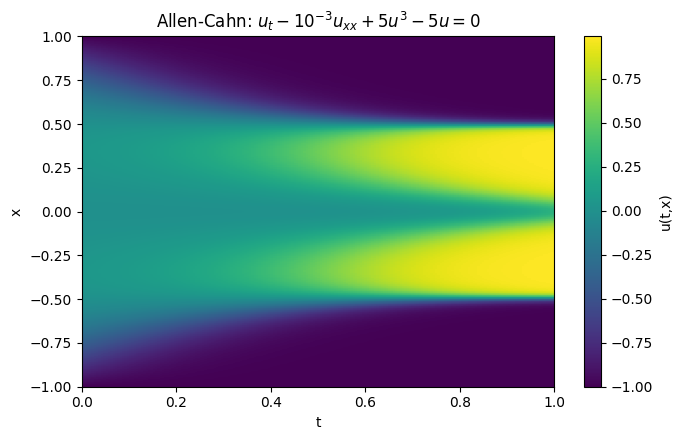

In [1]:
import numpy as np
import scipy.io
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# PDE:
# u_t = eps*u_xx + a*u - a*u^3
# equivalent:
# u_t - eps*u_xx + a*u^3 - a*u = 0

eps = 1e-3
a = 5.0

nx = 512
nt = 201

x = np.linspace(-1.0, 1.0, nx, endpoint=False)
t = np.linspace(0.0, 1.0, nt)

L = 2.0
dx = L / nx

# Fourier wavenumbers for domain length 2
k = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
k2 = k**2

# IC
u0 = x**2 * np.cos(np.pi * x)

def rhs(t, u):
    u_hat = np.fft.fft(u)
    u_xx = np.fft.ifft(-k2 * u_hat).real
    return eps * u_xx + a * u - a * u**3

sol = solve_ivp(
    rhs,
    (t[0], t[-1]),
    u0,
    t_eval=t,
    method="BDF",      # good for stiff Allen-Cahn
    rtol=1e-8,
    atol=1e-10,
)

if not sol.success:
    raise RuntimeError(sol.message)

usol = sol.y.T  # shape (nt, nx)

# Add periodic endpoint like MATLAB x = linspace(-1,1,nn+1)
x_full = np.linspace(-1.0, 1.0, nx + 1)
usol_full = np.concatenate([usol, usol[:, :1]], axis=1)

print("t:", t.shape)
print("x:", x_full.shape)
print("usol:", usol_full.shape)

scipy.io.savemat(
    "allen_cahn_python.mat",
    {
        "t": t,
        "x": x_full,
        "usol": usol_full,
        "eps": eps,
        "a": a,
    },
)

# Heatmap
plt.figure(figsize=(7, 4.5))
plt.imshow(
    usol_full.T,
    origin="lower",
    aspect="auto",
    extent=[t[0], t[-1], x_full[0], x_full[-1]],
    interpolation="nearest",
)
plt.colorbar(label="u(t,x)")
plt.xlabel("t")
plt.ylabel("x")
plt.title(r"Allen-Cahn: $u_t - 10^{-3}u_{xx}+5u^3-5u=0$")
plt.tight_layout()
plt.savefig("allen_cahn_python_heatmap.png", dpi=300)
plt.show()